# Density based clustering

In this section we perform a density based clustering over our clean merged dataset.

In order to do this, we use the **DBSCAN** algorithm (**Density-Based Spatial Clustering of Applications with Noise**), designed to identify groups of densely packed points while marking isolated observations as noise.

## DBSCAN Algorithm

Instead of relying on predefined cluster shapes or the number of clusters, DBSCAN **classifies data points based on local density**. Each point is assigned to one of three categories:

- **core points**, which have a sufficient number of neighboring points within a specified radius;
- **border points**, which lie close to core points but do not themselves meet the density requirement;
- **noise points**, which do not belong to any dense region.

The behavior of DBSCAN is primarily governed by two parameters:

- **$\epsilon$**, which defines the maximum distance between two points to be considered neighbors;
- **MinPts**, the minimum number of points required to form a dense region.

Tuning these parameters is essential, as they directly influence cluster shapes, the identification of noise, and the algorithm’s overall sensitivity to data distribution.

DBSCAN offers several _strengths_: it can discover clusters of arbitrary shapes, is robust to outliers, and does not require the number of clusters to be specified beforehand.

However, it also presents some _limitations_; its performance is sensitive to the choice of $\epsilon$ and MinPts, and selecting appropriate values may be challenging, especially in high-dimensional spaces. Additionally, DBSCAN struggles when clusters have varying densities, as a single global parameter set may not accurately capture all underlying structures.

In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import umap.umap_ as umap
import seaborn as sns
from scipy.stats import gaussian_kde
from s_dbw import S_Dbw
import warnings
warnings.filterwarnings("ignore")


In [53]:
df = pd.read_csv("../clustering_dataset/merged_dataset_clean.csv")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: 8144 rows x 14 columns
Columns: ['avg_token_per_clause', 'duration_ms', 'popularity', 'swear_ratio', 'syntactic_complexity', 'flow_complexity', 'percussiveness', 'harmonic_richness', 'trap_index', 'boombap_index', 'cloud_rap_index', 'drill_index', 'career_longevity', 'years_since_release']


In [26]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

print(f"Dataset shape after normalization: {X.shape[0]} rows x {X.shape[1]} columns")

Dataset shape after normalization: 8144 rows x 14 columns


## Dataset Distribution

Given that the density characteristics of the dataset are a sensitive topic for the DBSCAN algorithm, we explored these patterns beforhand.

We first examined the **distribution of k-nearest-neighbor distances**. Plotting these distances provides insight into how points are spread in the feature space and helps identify natural “density breaks” that can guide the selection of the $\epsilon$ parameter.

Additionally, visualizing the data’s density through scatter plots colored by local density and using a **Gaussian Kernel Density Estimate (KDE)**, allows us to observe regions where points accumulate more tightly.

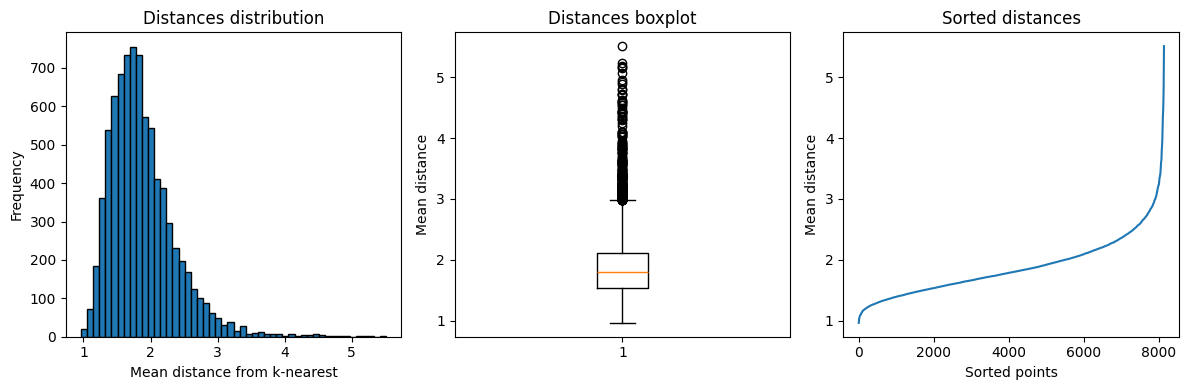

Mean: 1.8813
Std Dev: 0.4971
Variation Coefficient: 0.2642
Min: 0.96236037522805639721, Max: 5.51218310066697014804
Max/Min: 5.73


In [191]:
def dataset_distribution(X, k):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    # Mean distance for each point
    mean_distances = distances.mean(axis=1)

    # Visualizing the distribution
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.hist(mean_distances, bins=50, edgecolor='black')
    plt.xlabel("Mean distance from k-nearest")
    plt.ylabel("Frequency")
    plt.title("Distances distribution")

    plt.subplot(1, 3, 2)
    plt.boxplot(mean_distances)
    plt.ylabel("Mean distance")
    plt.title("Distances boxplot")

    plt.subplot(1, 3, 3)
    sorted_distances = np.sort(mean_distances)
    plt.plot(sorted_distances)
    plt.xlabel("Sorted points")
    plt.ylabel("Mean distance")
    plt.title("Sorted distances")
    plt.tight_layout()
    plt.show()

    # Statistics
    print(f"Mean: {mean_distances.mean():.4f}")
    print(f"Std Dev: {mean_distances.std():.4f}")
    print(f"Variation Coefficient: {mean_distances.std() / mean_distances.mean():.4f}")
    print(f"Min: {mean_distances.min():.20f}, Max: {mean_distances.max():.20f}")
    print(f"Max/Min: {mean_distances.max() / mean_distances.min():.2f}")
    return

dataset_distribution(X, k=15)

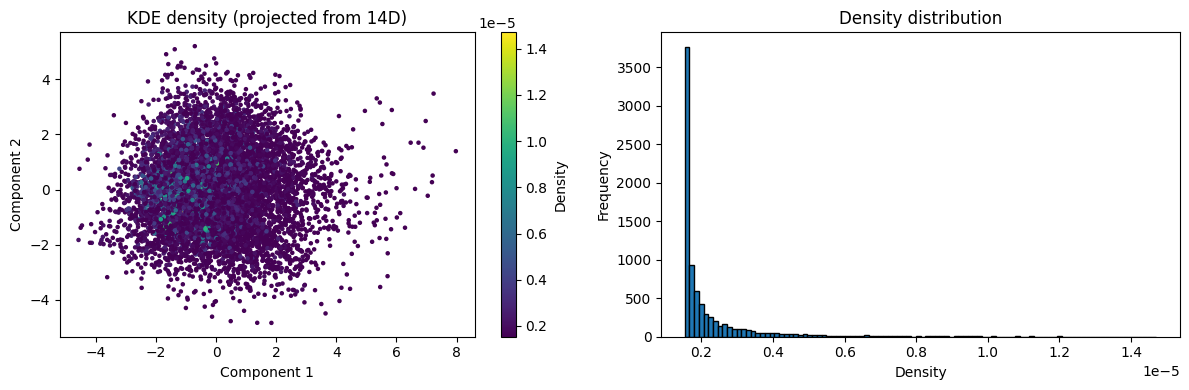

Density - Min: 0.0000015348, Max: 0.0000147078
Max/Min ratio: 9.58


In [192]:
def gaussian_KDE(X, n_components_visualization):
    kde = gaussian_kde(X.T)
    density = kde(X.T)

    # PCA for 2D visualization
    pca = PCA(n_components=n_components_visualization)
    X_vis = pca.fit_transform(X)

    plt.figure(figsize=(12, 4))

    # Scatter plot for density
    plt.subplot(1, 2, 1)
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=density, cmap='viridis', s=5)
    plt.colorbar(label="Density")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(f"KDE density (projected from {X.shape[1]}D)")

    # Densities histogram
    plt.subplot(1, 2, 2)
    plt.hist(density, bins=100, edgecolor='black')
    plt.xlabel("Density")
    plt.ylabel("Frequency")
    plt.title("Density distribution")
    plt.tight_layout()
    plt.show()

    print(f"Density - Min: {density.min():.10f}, Max: {density.max():.10f}")
    print(f"Max/Min ratio: {density.max() / density.min():.2f}")
    return

gaussian_KDE(X, n_components_visualization=2)

### Comments on the dataset

When applying DBSCAN, a preliminary density analysis should ideally reveal clear differences between dense regions (potential clusters) and sparse regions (potential noise). In a well-structured dataset for DBSCAN, the density distribution typically shows multiple peaks or at least a noticeable separation between high-density and low-density areas. A Gaussian KDE, in this context, should highlight heterogeneous density zones, forming distinguishable areas with significantly higher concentration of points compared to the background.

In contrast, **our dataset does not display these desirable properties**.

The KDE reveals extremely low and almost uniform density values, with a very small density range and a Max/Min ratio of only 9.58. This indicates that the dataset lacks pronounced high-density regions. The "Density distribution" plot further confirms this issue: it shows a single peak at the lowest density values, followed by a curve that rapidly flattens near zero. This behavior means that most points share similarly sparse density levels, and no meaningful density contrast emerges.

Because DBSCAN relies on identifying dense neighborhoods to form clusters, the absence of well-defined density variations makes it nearly impossible for the algorithm to distinguish cores, borders, and noise in a meaningful way. As a consequence, DBSCAN is likely to either label almost all points as noise or merge most of the dataset into a single, poorly defined cluster.

## Grid search to find "optimal" parameters

Although the density analysis indicates that the dataset is not well suited for DBSCAN, we still perform a systematic parameter exploration for academic purposes.

To do so, we begin by plotting the k-distance curves for two representative values of $k$. These plots help visualize how the neighborhood distances evolve as $k$ increases and provide a baseline for defining a reasonable search space for $\epsilon$.

Since the dataset does not exhibit a clear density separation, we rely on a more general heuristic: we compute the 1st and 95th percentiles of the k-distances and use them as the lower and upper bounds for $\epsilon$. This approach ensures that the values considered in the grid search span the range of typical neighborhood distances without being overly influenced by extreme outliers.

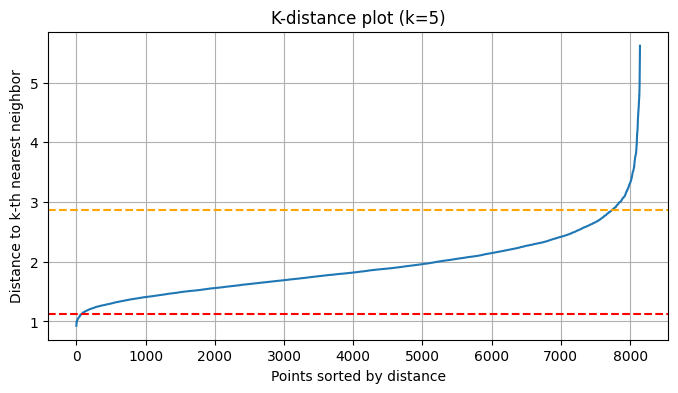

k=5| epsilon_min: 1.129641737268356, epsilon_max: 2.8665654070377142


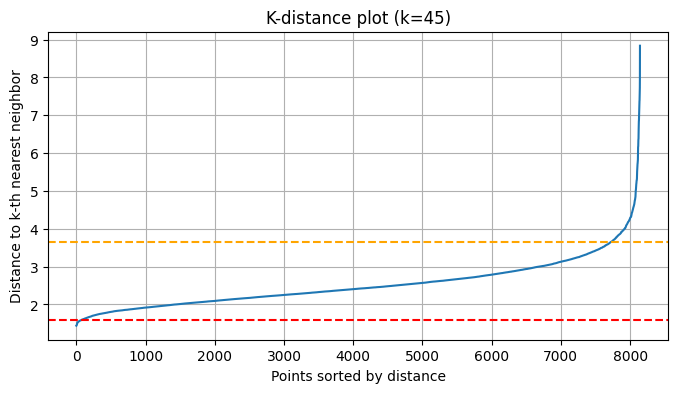

k=45| epsilon_min: 1.5967928754619147, epsilon_max: 3.663369588588388


In [15]:
def plot_k_distance(X, k):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors.fit(X)
    distances, indices = neighbors.kneighbors(X)

    # sorting distances from k-nearest
    k_distances = np.sort(distances[:, k-1])

    # Finding a range for epsilon
    eps_min = np.percentile(k_distances, 1)
    eps_max = np.percentile(k_distances, 95)

    plt.figure(figsize=(8,4))
    plt.plot(k_distances)
    plt.axhline(y=eps_min, color='red', linestyle='--', label=f"eps_min = {eps_min:.2f}")
    plt.axhline(y=eps_max, color='orange', linestyle='--', label=f"eps_max = {eps_max:.2f}")
    plt.title(f"K-distance plot (k={k})")
    plt.xlabel("Points sorted by distance")
    plt.ylabel("Distance to k-th nearest neighbor")
    plt.grid(True)
    plt.show()

    return eps_min, eps_max

eps_min, eps_max = plot_k_distance(X, k=5)
print(f"k=5| epsilon_min: {eps_min}, epsilon_max: {eps_max}")

eps_min, eps_max = plot_k_distance(X, k=45)
print(f"k=45| epsilon_min: {eps_min}, epsilon_max: {eps_max}")

With these bounds defined, we perform a grid search by varying $k$ from 5 to 45 and sampling $\epsilon$ uniformly between the selected percentile-based limits.

This exploration allows us to observe how DBSCAN behaves across a broad range of parameter combinations, even though we do not expect well-formed clusters due to the dataset’s nearly uniform density distribution.

The resulting cluster configurations, often trivial, unstable, or highly sensitive to small parameter variations, highlight the challenges of applying DBSCAN when the underlying data structure lacks the density contrasts required by the algorithm.

In [194]:
eps_values = np.linspace(1.1, 3.7, 30)
min_samples = list(range(5, 46))

def grid_search(X, top_n=10):
    all_results = []
    
    for k in min_samples:
        for eps in eps_values:
            dbscan = DBSCAN(eps=eps, min_samples=k, metric='euclidean')
            clusters = dbscan.fit_predict(X)
            n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
            n_noise = (clusters == -1).sum()
            noise_pct = n_noise / len(clusters) * 100
            
            if 2 <= n_clusters <= 10 and noise_pct < 40:
                unique, counts = np.unique(clusters, return_counts=True)
                non_noise_mask_idx = unique != -1
                non_noise_counts = counts[non_noise_mask_idx]
                
                if len(non_noise_counts) > 0 and np.all(non_noise_counts >= 30):
                    non_noise_mask = clusters != -1
                    sil = -1
                    if non_noise_mask.sum() >= 2:
                        try:
                            sil = silhouette_score(X[non_noise_mask], clusters[non_noise_mask])
                        except:
                            sil = -1
                    
                    all_results.append((eps, k, n_clusters, n_noise, sil))
    
    all_results.sort(key=lambda t: (-t[2], t[3], -t[4]), reverse=False)
    
    results = all_results[:top_n]
    
    for eps, k, n_clusters, n_noise, sil in results:
        print(f"eps={eps:.3f}, min_samples={k}, clusters={n_clusters}, "
              f"noise={n_noise}, silhouette={sil:.3f}")
    
    return results

grid_search(X, top_n=10)

eps=2.086, min_samples=34, clusters=2, noise=2750, silhouette=0.188
eps=2.086, min_samples=35, clusters=2, noise=2770, silhouette=0.189
eps=2.086, min_samples=36, clusters=2, noise=2823, silhouette=0.191
eps=2.086, min_samples=37, clusters=2, noise=2855, silhouette=0.185
eps=2.086, min_samples=38, clusters=2, noise=2903, silhouette=0.187
eps=1.997, min_samples=21, clusters=2, noise=2915, silhouette=0.188
eps=2.086, min_samples=39, clusters=2, noise=2927, silhouette=0.188
eps=2.086, min_samples=40, clusters=2, noise=2948, silhouette=0.188
eps=1.997, min_samples=22, clusters=2, noise=2961, silhouette=0.189
eps=2.086, min_samples=41, clusters=2, noise=2977, silhouette=0.189


[(np.float64(2.086206896551724), 34, 2, np.int64(2750), 0.1882014649794904),
 (np.float64(2.086206896551724), 35, 2, np.int64(2770), 0.188683281929775),
 (np.float64(2.086206896551724), 36, 2, np.int64(2823), 0.19088598076514185),
 (np.float64(2.086206896551724), 37, 2, np.int64(2855), 0.18500525936789874),
 (np.float64(2.086206896551724), 38, 2, np.int64(2903), 0.18737879200878893),
 (np.float64(1.9965517241379311), 21, 2, np.int64(2915), 0.1880894605147664),
 (np.float64(2.086206896551724), 39, 2, np.int64(2927), 0.18766811292573532),
 (np.float64(2.086206896551724), 40, 2, np.int64(2948), 0.18824069019371248),
 (np.float64(1.9965517241379311), 22, 2, np.int64(2961), 0.1886351452092601),
 (np.float64(2.086206896551724), 41, 2, np.int64(2977), 0.18920513339802297)]

## Clustering with best parameter

After identifying the most suitable parameter combination for our dataset, we rerun DBSCAN using these optimized values and focus on evaluating the resulting clustering.

The goal at this stage is not only to visualize the cluster assignments but also to assess the quality and stability of the partition obtained.

In [27]:
dbscan = DBSCAN(
    eps=2.086206896551724,
    min_samples=34,
    metric='euclidean'
)
clusters = dbscan.fit_predict(X)

### Clustering validity

To evaluate the quality of the clustering produced by DBSCAN, we rely on two complementary validity indices: the silhouette score and the S_Dbw index.

The **silhouette score** ranges from –1 to 1. Values close to 1 indicate well-separated and compact clusters, while values around 0 suggest overlapping or weakly defined cluster boundaries and values below 0 imply that points may be assigned to the wrong cluster.

The **S_Dbw index**, on the other hand, has a range starting from 0 and extending to positive values without a fixed upper bound. Since it measures cluster compactness and inter-cluster density, lower values indicate better clustering solutions, while higher values correspond to less compact or poorly separated clusters.

Taken together, these indices provide a more complete validation: the silhouette score captures distance-based separation, whereas S_Dbw focuses on density and variance—properties closely aligned with DBSCAN’s density-based nature.

In [10]:
mask = clusters != -1
X_no_noise = X[mask]
clusters_no_noise = clusters[mask]

# Silhouette Score
if len(set(clusters_no_noise)) > 1:
    sil = silhouette_score(X_no_noise, clusters_no_noise)
else:
    sil = np.nan

print("Silhouette Score:", sil)


# S-Dwb Index
if len(np.unique(clusters_no_noise)) > 1:
    sdbw = S_Dbw(X_no_noise, clusters_no_noise)
else:
    sdbw = np.nan

print("S_Dbw Index:", sdbw)

Silhouette Score: 0.1882014649794904
S_Dbw Index: 0.7265872423727125


### Clustering visualization

To better understand the clustering structure, we visualize the DBSCAN results using both **PCA** and **UMAP**. Although both methods reduce dimensionality, they capture different aspects of the data.

**PCA** performs a _linear projection_ that preserves as much global variance as possible, often resulting in smooth, continuous shapes where clusters may appear less separated if the underlying structure is nonlinear.

In contrast, **UMAP** is a _nonlinear manifold-learning method_ designed to preserve local neighborhood relationships. As a result, UMAP typically highlights small-scale structure more effectively, making compact or irregularly shaped clusters appear more distinct in the embedding. However, UMAP can introduce distortions in global distances, meaning that the relative positioning of distant clusters may not reflect true relationships in the original space.

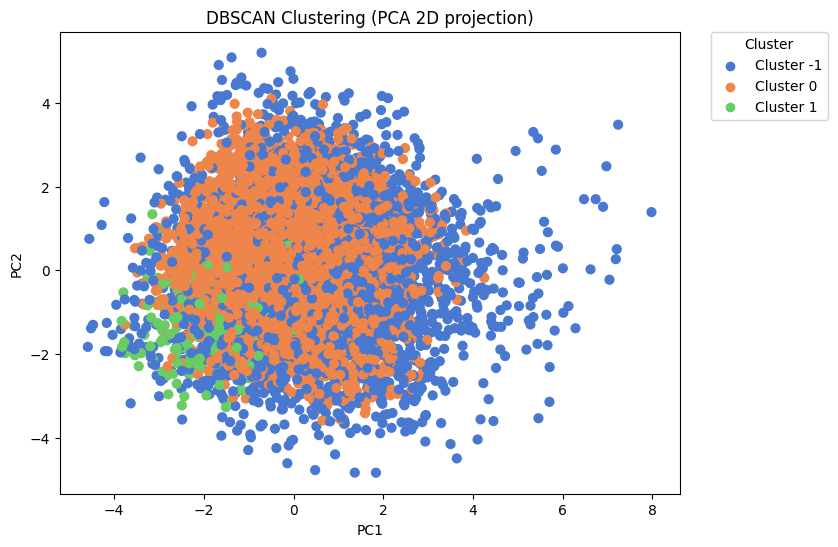

In [35]:
unique_clusters = np.unique(clusters)

# Cluster-color ditionary
palette = sns.color_palette("muted", len(unique_clusters))
color_map = {cl: palette[i] for i, cl in enumerate(unique_clusters)}

colors = [color_map[c] for c in clusters]

def PCA_visualization(X):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=colors, s=40)

    for cl in unique_clusters:
        plt.scatter([], [], color=color_map[cl], label=f"Cluster {cl}")

    plt.legend(
        title="Cluster",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.
    )
    plt.title("DBSCAN Clustering (PCA 2D projection)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
    
    return

PCA_visualization(X)

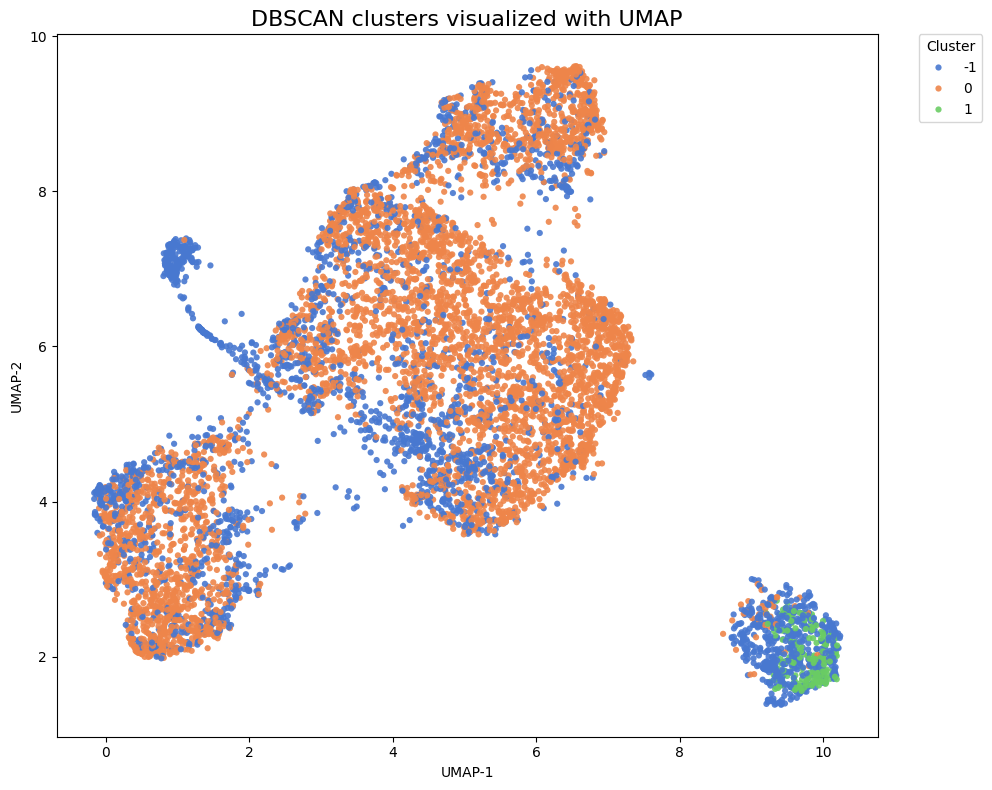

In [36]:
def UMAP_visualization(X):
    reducer = umap.UMAP(
        n_neighbors=40,
        min_dist=0.0,
        metric='euclidean',
        n_jobs=1
    )

    X_umap = reducer.fit_transform(X)

    df_vis = pd.DataFrame({
        "UMAP1": X_umap[:,0],
        "UMAP2": X_umap[:,1],
        "cluster": clusters
    })

    ordered_palette = [color_map[cl] for cl in unique_clusters]

    plt.figure(figsize=(10,8))

    sns.scatterplot(data=df_vis, x="UMAP1", y="UMAP2", hue="cluster",
                    hue_order=unique_clusters, palette=ordered_palette,
                    s=20, linewidth=0, alpha=0.9)

    plt.title("DBSCAN clusters visualized with UMAP", fontsize=16)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    plt.legend(
        title="Cluster",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.
    )

    plt.tight_layout()
    plt.show()

    return

UMAP_visualization(X)

In both the PCA and UMAP visualizations, a large number of points are labeled as noise by DBSCAN.

Where cluster separation is visible, it appears quite clear, suggesting that some structure does exist in the data. The UMAP projection makes this even more apparent: it displays several visually well-separated groups that, in principle, could correspond to meaningful clusters. Despite this, **DBSCAN fails to recognize them**.

Instead, noise points are scattered across all these visually distinct regions, preventing the algorithm from identifying them as actual clusters. As a result, only one group receives a distinct cluster label, while all other regions—although clearly separated in the UMAP embedding—remain unlabeled and are classified almost entirely as noise.

This discrepancy highlights how the underlying density distribution of the dataset, rather than the geometric separation visible in the embeddings, limits DBSCAN’s ability to form stable and coherent clusters.

## Reducing dataset dimensionality

Although clustering algorithms should ideally be compared on the same dataset to ensure fairness, we also decided to explore DBSCAN’s potential by reducing the dataset to what we consider the most significant features.

The goal of this step is not to alter the comparison framework, but to investigate whether a lower-dimensional and potentially more informative representation might better align with DBSCAN’s density-based assumptions.

After selecting these key features, we repeated the entire procedure described above: density analysis, k-distance inspection, grid searches for $k$ and $\epsilon$ and clustering evaluation. The final aim is to assess whether dimensionality reduction yields more meaningful or stable clustering results.

In [58]:
df = df.copy()

selected_features = [
    "percussiveness",
    "harmonic_richness",
    "trap_index"
    ]

df_dbscan = df[selected_features]

print(f"New dataset shape: {df_dbscan.shape[0]} rows x {df_dbscan.shape[1]} columns")


New dataset shape: 8144 rows x 3 columns


In [59]:
scaler = StandardScaler()
X = scaler.fit_transform(df_dbscan)

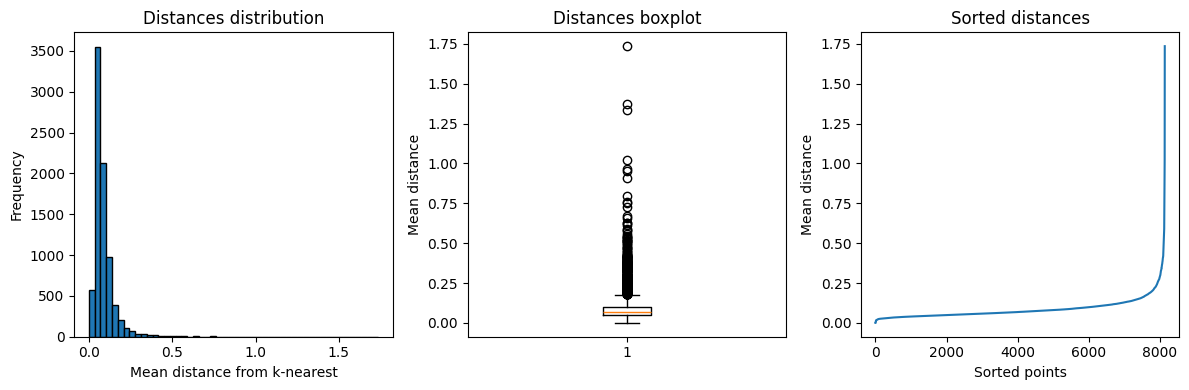

Mean: 0.0861
Std Dev: 0.0702
Variation Coefficient: 0.8152
Min: 0.00000000000000000000, Max: 1.73549787104464292575
Max/Min: inf


In [244]:
dataset_distribution(X, k=4)

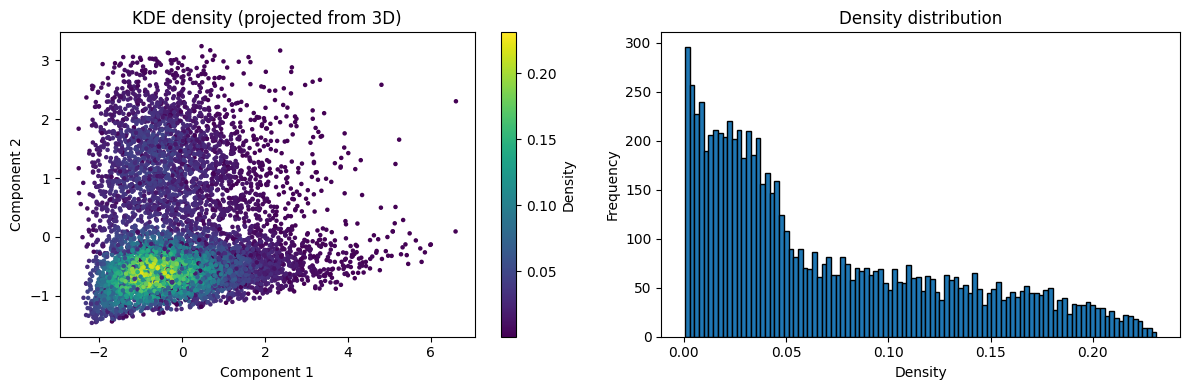

Density - Min: 0.0004896065, Max: 0.2311016602
Max/Min ratio: 472.02


In [245]:
gaussian_KDE(X, n_components_visualization=2)

The analysis of the **k-distances** reveals a strong heterogeneity in the neighborhood structure of the reduced dataset. The mean distance is relatively small, but the standard deviation is almost as large, resulting in a high variation coefficient, which indicates substantial variability in point densities. Furthermore the range is extremely wide and the Max/Min ratio is infinite due to the presence of distances extremely close to zero. This suggests that some points are tightly packed together while others lie in very sparse regions.

The **Gaussian KDE** provides further confirmation of this heterogeneous density structure. The density values cover a broad interval, with a Max/Min ratio far larger than the ratio observed before feature reduction. In the 2D KDE visualization, a distinct high-density region clearly emerges, indicating the presence of at least one compact and well-defined cluster. Meanwhile, the density distribution plot shows a large concentration of points at lower densities, followed by an extended plateau where the frequency remains roughly constant for higher density values.

This pattern is encouraging from a DBSCAN perspective: unlike the original dataset, the reduced feature space displays marked density contrasts. The presence of a clearly identifiable high-density region and a non-uniform density distribution suggests that DBSCAN may now be better positioned to separate meaningful clusters from noise.

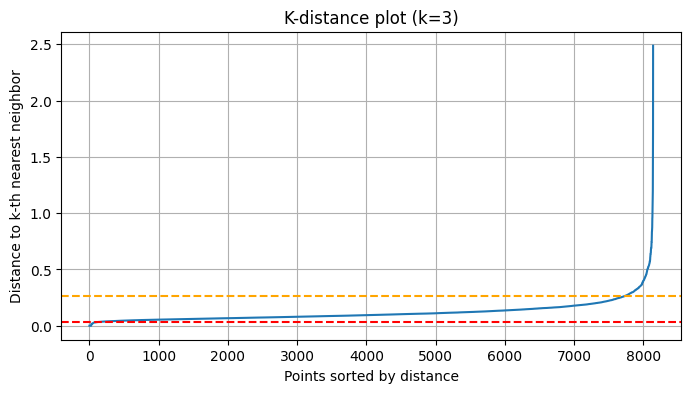

k=3| epsilon_min: 0.02920619319597699, epsilon_max: 0.26414978908506015


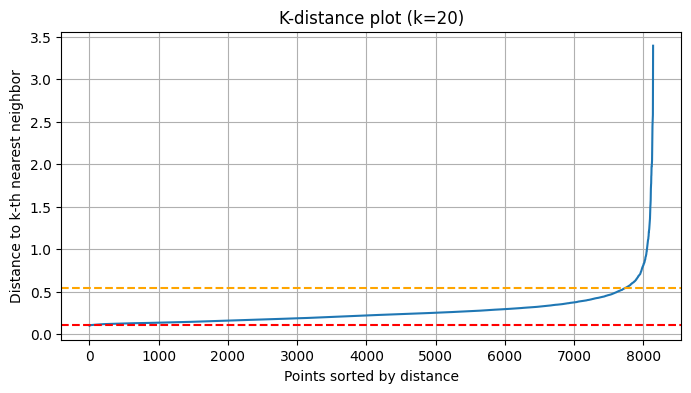

k=15| epsilon_min: 0.11061614840558312, epsilon_max: 0.5400635848318487


In [19]:
eps_min, eps_max = plot_k_distance(X, k=3)
print(f"k=3| epsilon_min: {eps_min}, epsilon_max: {eps_max}")

eps_min, eps_max = plot_k_distance(X, k=20)
print(f"k=15| epsilon_min: {eps_min}, epsilon_max: {eps_max}")

In [ ]:
eps_values = np.linspace(0.02, 0.6, 30)
min_samples = list(range(3, 20))

grid_search(X, top_n=10)

eps=0.208, min_samples=18, clusters=5, noise=3048, silhouette=0.243
eps=0.372, min_samples=10, clusters=2, noise=287, silhouette=0.502
eps=0.278, min_samples=17, clusters=2, noise=1206, silhouette=0.089
eps=0.278, min_samples=18, clusters=2, noise=1258, silhouette=0.084
eps=0.254, min_samples=18, clusters=2, noise=1653, silhouette=0.378
eps=0.231, min_samples=17, clusters=2, noise=2101, silhouette=0.312


[(np.float64(0.2075862068965517), 18, 5, np.int64(3048), 0.24306194113552415),
 (np.float64(0.3717241379310344), 10, 2, np.int64(287), 0.5023956452115906),
 (np.float64(0.2779310344827586), 17, 2, np.int64(1206), 0.08866320906789134),
 (np.float64(0.2779310344827586), 18, 2, np.int64(1258), 0.08361618712635467),
 (np.float64(0.25448275862068964), 18, 2, np.int64(1653), 0.37805943161031746),
 (np.float64(0.23103448275862065), 17, 2, np.int64(2101), 0.31179182317159637)]

In [60]:
dbscan = DBSCAN(
    eps=0.2075862068965517,
    min_samples=18,
    metric='euclidean'
)
clusters = dbscan.fit_predict(X)

### Clustering validity & visualization

In [20]:
mask = clusters != -1
X_no_noise = X[mask]
clusters_no_noise = clusters[mask]

# Silhouette Score
if len(set(clusters_no_noise)) > 1:
    sil = silhouette_score(X_no_noise, clusters_no_noise)
else:
    sil = np.nan

print("Silhouette Score:", sil)


# S-Dwb Index
if len(np.unique(clusters_no_noise)) > 1:
    sdbw = S_Dbw(X_no_noise, clusters_no_noise)
else:
    sdbw = np.nan

print("S_Dbw Index:", sdbw)

Silhouette Score: 0.22088599118766747
S_Dbw Index: 0.6657342165374006


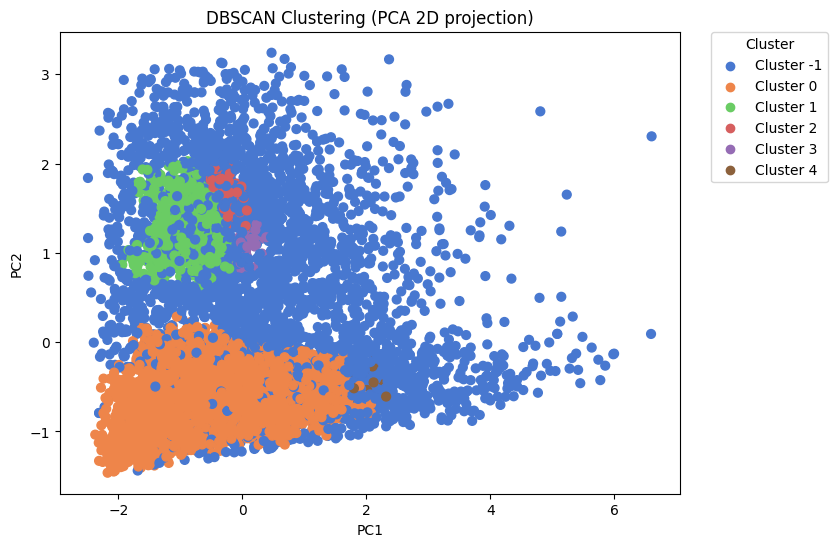

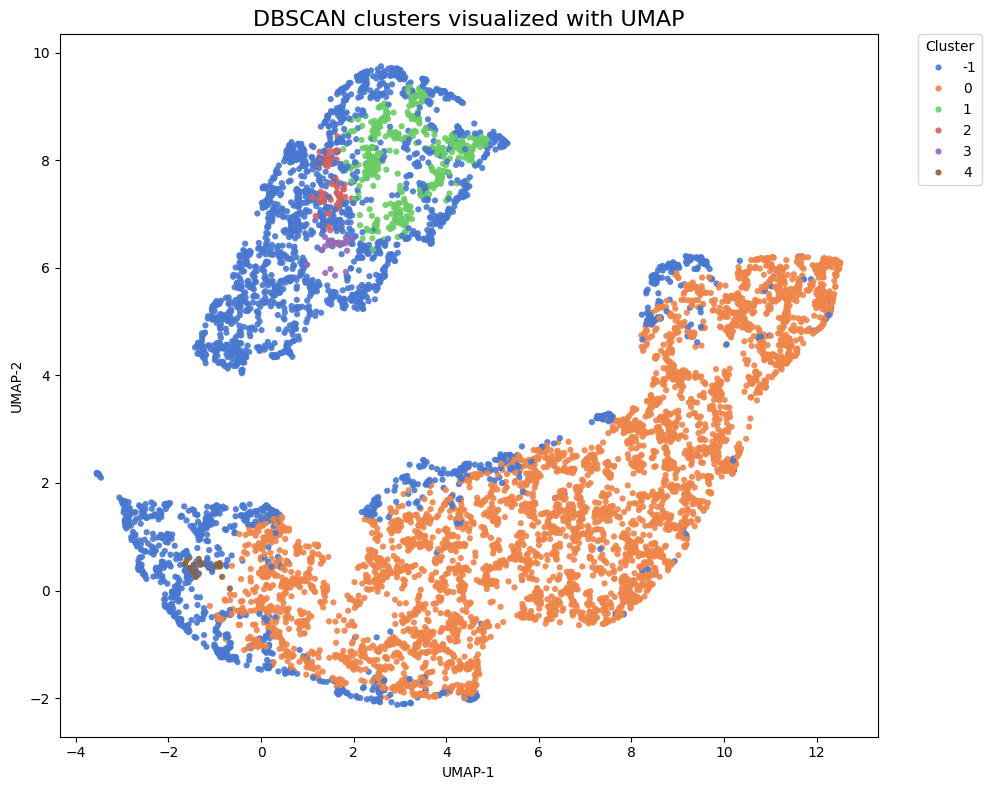

In [61]:
unique_clusters = np.unique(clusters)

# Cluster-color ditionary
palette = sns.color_palette("muted", len(unique_clusters))
color_map = {cl: palette[i] for i, cl in enumerate(unique_clusters)}

colors = [color_map[c] for c in clusters]

PCA_visualization(X)

UMAP_visualization(X)

Applying DBSCAN after reducing the dataset to the most meaningful features results in the identification of five clusters. Although these clusters are not perfectly separated, their structure appears considerably more coherent than in the full-dimensional dataset, especially in the PCA visualization where the grouping is more interpretable than in UMAP.

The improvement is also reflected in the validity indices: the **silhouette score** increases from $0.19$ to $0.22$, while the **S_Dbw index** decreases from $0.73$ to $0.67$, both indicating a modest but consistent gain in cluster cohesion and separation.

Given the nature of the selected features, chosen specifically to enhance the discriminative structure of the dataset, we would have expected to identify 3-4 well-separated clusters, potentially of different sizes. The fact that DBSCAN produced five groups, some of which still exhibit partial overlap or unclear boundaries, suggests that **the dataset retains a degree of density irregularity even after dimensionality reduction**.

Nonetheless, the overall result shows a definite improvement and supports the intuition that the reduced feature space better aligns with the density-based assumptions of DBSCAN.